In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/WeatherDiseaseApp/Weather-related disease prediction.csv')

In [3]:
df

,Age,Gender,Temperature (C),Humidity,Wind Speed (km/h),nausea,joint_pain,abdominal_pain,high_fever,chills,...,facial_pain,shortness_of_breath,reduced_smell_and_taste,skin_irritation,itchiness,throbbing_headache,confusion,back_pain,knee_ache,prognosis
0,4,1,25.826000,0.740000,8.289000,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Heart Attack
1,55,0,21.628000,0.600000,15.236000,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,Influenza
2,45,0,13.800000,0.817083,4.291992,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Influenza
3,6,0,37.254000,0.610000,18.009000,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Dengue
4,70,0,18.162000,0.870000,17.916000,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,Sinusitis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,91,1,21.714000,0.870000,5.450000,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,Arthritis
5196,83,0,10.491000,0.920000,9.165000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Stroke
5197,77,0,19.942824,0.744583,9.305129,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Influenza
5198,84,0,20.069000,0.850000,17.971000,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,Heart Attack


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5200 non-null   int64  
 1   Gender                   5200 non-null   int64  
 2   Temperature (C)          5200 non-null   float64
 3   Humidity                 5200 non-null   float64
 4   Wind Speed (km/h)        5200 non-null   float64
 5   nausea                   5200 non-null   int64  
 6   joint_pain               5200 non-null   int64  
 7   abdominal_pain           5200 non-null   int64  
 8   high_fever               5200 non-null   int64  
 9   chills                   5200 non-null   int64  
 10  fatigue                  5200 non-null   int64  
 11  runny_nose               5200 non-null   int64  
 12  pain_behind_the_eyes     5200 non-null   int64  
 13  dizziness                5200 non-null   int64  
 14  headache                

In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Temperature (C),0
Humidity,0
Wind Speed (km/h),0
nausea,0
joint_pain,0
abdominal_pain,0
high_fever,0
chills,0


In [6]:
df['prognosis'].unique()

array(['Heart Attack', 'Influenza', 'Dengue', 'Sinusitis', 'Eczema',
       'Common Cold', 'Heat Stroke', 'Migraine', 'Malaria', 'Arthritis',
       'Stroke'], dtype=object)

In [7]:
value_counts = df.groupby('prognosis').size().reset_index(name='Count') # This is the most effective way to understand unique value.
print(value_counts)

       prognosis  Count
0      Arthritis    311
1    Common Cold    321
2         Dengue    322
3         Eczema    327
4   Heart Attack   1013
5    Heat Stroke    338
6      Influenza    658
7        Malaria    330
8       Migraine    941
9      Sinusitis    310
10        Stroke    329


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['prognosis'] = le.fit_transform(df['prognosis'])

In [ ]:
df['prognosis']

,prognosis
0,4
1,6
2,6
3,2
4,9
...,...
5195,0
5196,10
5197,6
5198,4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

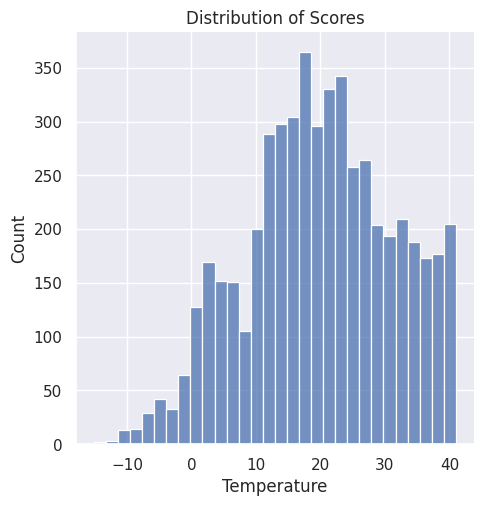

In [ ]:
sns.set_theme(color_codes="red")
sns.displot(data=df['Temperature (C)']).set(title="Distribution of Scores", xlabel="Temperature")

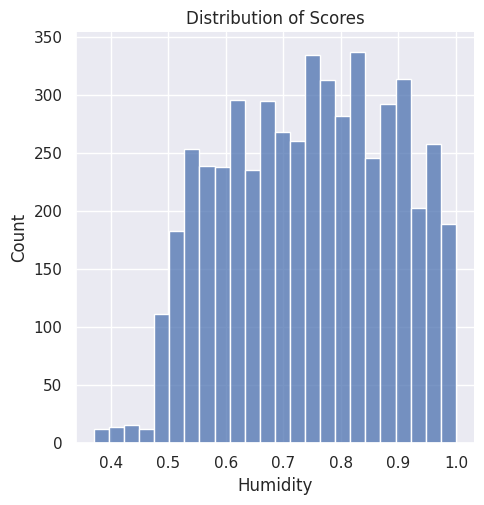

In [ ]:
sns.set_theme(color_codes="red")
sns.displot(data=df['Humidity']).set(title="Distribution of Scores", xlabel="Humidity")

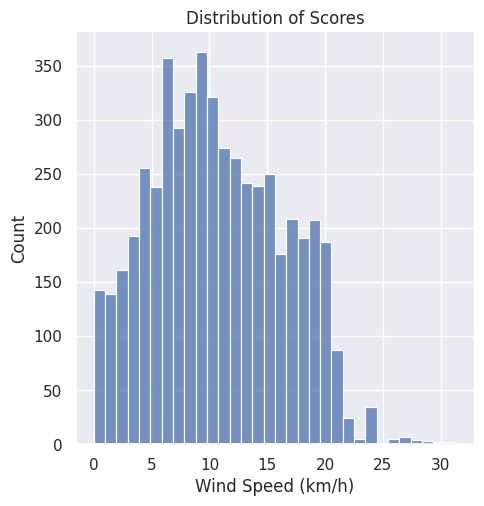

In [ ]:
sns.set_theme(color_codes="red")
sns.displot(data=df['Wind Speed (km/h)']).set(title="Distribution of Scores", xlabel="Wind Speed (km/h)")

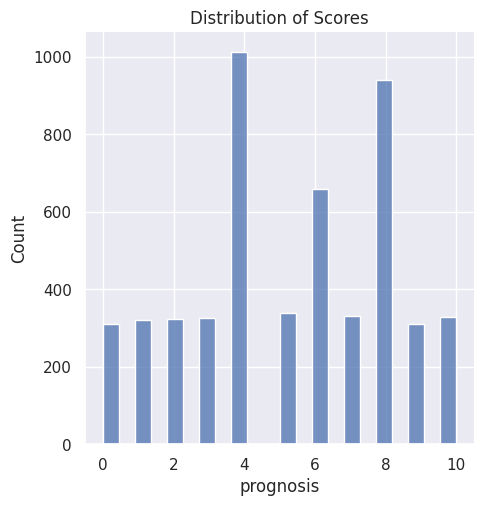

In [ ]:
sns.set_theme(color_codes="red")
sns.displot(data=df['prognosis']).set(title="Distribution of Scores", xlabel="prognosis")

In [ ]:
z_score1 = (df['Temperature (C)'] - df['Temperature (C)'].mean()) / df['Temperature (C)'].std()
z_score1

,Temperature (C)
0,0.515369
1,0.147604
2,-0.538166
3,1.516516
4,-0.156034
...,...
5195,0.155138
5196,-0.828050
5197,-0.000026
5198,0.011028


In [ ]:
for i in z_score1:
  if i < -3:
    print("You have outlier", i)
  elif i > 3:
    print("You have outlier", i)
  else:
    continue

You have outlier -3.072133811510454
You have outlier -3.072133811510454


In [ ]:
index = z_score1.index[z_score1 == -3.072133811510454][0]
index

np.int64(2562)

In [ ]:
df['Temperature (C)'][2562]

np.float64(-15.125)

In [ ]:
Temp_mean = df['Temperature (C)'].mean()                                # We are replacing the outlier value with the mean value.
df.loc[2562, "Temperature (C)"] = Temp_mean

df['Temperature (C)'][2562]

np.float64(19.943117134459037)

In [ ]:
z_score2 = (df['Humidity'] - df['Humidity'].mean()) / df['Humidity'].std()
z_score2

,Humidity
0,-0.034107
1,-1.014085
2,0.505464
3,-0.944087
4,0.875873
...,...
5195,0.875873
5196,1.225865
5197,-0.002024
5198,0.735876


In [ ]:
for i in z_score2:
  if i < -3:
    print("You have outlier", i)
  elif i > 3:
    print("You have outlier", i)
  else:
    continue

In [ ]:
z_score3 = (df['Wind Speed (km/h)'] - df['Wind Speed (km/h)'].mean()) / df['Wind Speed (km/h)'].std()
z_score3

,Wind Speed (km/h)
0,-0.425550
1,0.796152
2,-1.128465
3,1.283812
4,1.267457
...,...
5195,-0.924817
5196,-0.271496
5197,-0.246853
5198,1.277130


In [ ]:
for i in z_score3:
  if i < -3:
    print("You have outlier", i)
  elif i > 3:
    print("You have outlier", i)
  else:
    continue

You have outlier 3.621716008188061
You have outlier 3.069484597573794
You have outlier 3.069484597573794
You have outlier 3.621716008188061
You have outlier 3.2570615990283422
You have outlier 3.2570615990283422
You have outlier 3.2570615990283422
You have outlier 3.3066102409219975
You have outlier 3.3066102409219975
You have outlier 3.069484597573794
You have outlier 3.069484597573794


In [ ]:
index1 = z_score3.index[z_score3 == 3.621716008188061][0]
index1

np.int64(545)

In [ ]:
df['Wind Speed (km/h)'][545]

np.float64(31.30309583)

In [ ]:
Wind_mean = df['Wind Speed (km/h)'].mean()                                # We are replacing the outlier value with the mean value.
df.loc[545, "Wind Speed (km/h)"] = Wind_mean

df['Wind Speed (km/h)'][545]

np.float64(10.708818241179424)

In [ ]:
correlations = df.corr(method='pearson')
print(correlations['prognosis'].sort_values(ascending=False).to_string())

prognosis                  1.000000
trouble_seeing             0.336231
weakness                   0.324864
vomiting                   0.281987
facial_pain                0.250830
reduced_smell_and_taste    0.241444
headache                   0.237545
sinus_headache             0.234003
nasal_polyps               0.220850
severe_headache            0.209103
dizziness                  0.193552
confusion                  0.152690
throbbing_headache         0.141617
hiv_aids                   0.127426
diarrhea                   0.122600
chills                     0.114768
pain_behind_the_eyes       0.089063
fever                      0.077697
rapid_breathing            0.052474
runny_nose                 0.037352
Wind Speed (km/h)         -0.006238
Humidity                  -0.013127
Gender                    -0.015185
rapid_heart_rate          -0.020310
body_aches                -0.021035
nausea                    -0.027024
shortness_of_breath       -0.030596
abdominal_pain            -0

In [ ]:
sns.set(font_scale=2)
plt.subplots(figsize=(50,50))

heat_plot = sns.heatmap(df.corr(method='pearson'), annot=True, cmap='RdYlGn', annot_kws={'size' : 20})  # pearson correlation / heatmap

plt.xticks(fontsize=35)
plt.yticks(fontsize=35)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df.drop('shivering', axis=1, inplace=True)
df.drop('asthma_history', axis=1, inplace=True)
df.drop('high_cholesterol', axis=1, inplace=True)
df.drop('diabetes', axis=1, inplace=True)
df.drop('obesity', axis=1, inplace=True)

In [ ]:
correlations = df.corr(method='pearson')
print(correlations['prognosis'].sort_values(ascending=False).to_string())

prognosis                  1.000000
trouble_seeing             0.336231
weakness                   0.324864
vomiting                   0.281987
facial_pain                0.250830
reduced_smell_and_taste    0.241444
headache                   0.237545
sinus_headache             0.234003
nasal_polyps               0.220850
severe_headache            0.209103
dizziness                  0.193552
confusion                  0.152690
throbbing_headache         0.141617
hiv_aids                   0.127426
diarrhea                   0.122600
chills                     0.114768
pain_behind_the_eyes       0.089063
fever                      0.077697
rapid_breathing            0.052474
runny_nose                 0.037352
Wind Speed (km/h)         -0.006238
Humidity                  -0.013127
Gender                    -0.015185
rapid_heart_rate          -0.020310
body_aches                -0.021035
nausea                    -0.027024
shortness_of_breath       -0.030596
abdominal_pain            -0

In [ ]:
sns.set(font_scale=2)
plt.subplots(figsize=(50,50))

heat_plot = sns.heatmap(df.corr(method='pearson'), annot=True, cmap='RdYlGn', annot_kws={'size' : 20})  # pearson correlation / heatmap

plt.xticks(fontsize=35)
plt.yticks(fontsize=35)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from sklearn.utils import shuffle
shuffled_df = shuffle(df)                 # Shuffle the dataset

shuffled_df

,Age,Gender,Temperature (C),Humidity,Wind Speed (km/h),nausea,joint_pain,abdominal_pain,high_fever,chills,...,facial_pain,shortness_of_breath,reduced_smell_and_taste,skin_irritation,itchiness,throbbing_headache,confusion,back_pain,knee_ache,prognosis
2705,89,0,30.531481,0.370833,13.707137,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
1222,90,1,18.077778,0.743333,6.695588,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
4623,33,0,29.833000,0.540000,17.813000,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,7
3415,69,1,39.330000,0.570000,2.439000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
311,82,0,0.203935,0.791250,12.359433,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,67,1,39.124000,0.620000,19.030000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
4752,79,0,17.483000,0.900000,2.700000,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
2180,76,0,-5.342130,0.838750,3.942487,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
2953,57,1,13.950926,0.660000,8.276742,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


In [ ]:
rearranged_df = shuffled_df.reset_index(drop=True)
rearranged_df

,Age,Gender,Temperature (C),Humidity,Wind Speed (km/h),nausea,joint_pain,abdominal_pain,high_fever,chills,...,facial_pain,shortness_of_breath,reduced_smell_and_taste,skin_irritation,itchiness,throbbing_headache,confusion,back_pain,knee_ache,prognosis
0,89,0,30.531481,0.370833,13.707137,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
1,90,1,18.077778,0.743333,6.695588,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
2,33,0,29.833000,0.540000,17.813000,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,7
3,69,1,39.330000,0.570000,2.439000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
4,82,0,0.203935,0.791250,12.359433,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,67,1,39.124000,0.620000,19.030000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
5196,79,0,17.483000,0.900000,2.700000,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
5197,76,0,-5.342130,0.838750,3.942487,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
5198,57,1,13.950926,0.660000,8.276742,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


In [ ]:
x = rearranged_df.drop(columns='prognosis')
y = rearranged_df['prognosis']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)

In [ ]:
!pip install hyperopt

In [ ]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials

In [ ]:
space = {'loss' : hp.choice('loss', ['log_loss']),
         'learning_rate' : hp.uniform('learning_rate', 0.1, 0.5),
         'n_estimators' : hp.choice('n_estimators', [10, 50, 100, 200]),
         'criterion' : hp.choice('criterion', ['friedman_mse', 'squared_error']),
         'min_samples_leaf' : hp.choice('min_samples_leaf', [1, 2, 3]),
         'min_samples_split' : hp.choice('min_samples_split', [2, 3, 4]),
         'max_depth' : hp.choice('max_depth', [3, 5, 10]),
         'min_impurity_decrease' : hp.uniform('min_impurity_decrease', 0, 0.5),
         'max_features' : hp.choice('max_features', ['sqrt', 'log2', None]),
         'max_leaf_nodes' : hp.choice('max_leaf_nodes', [2, 3, 4, None]),
         'tol' : hp.uniform('tol', 0.0001, 0.01) }

In [ ]:
space

{'loss': <hyperopt.pyll.base.Apply at 0x7cf762a3dc50>,
 'learning_rate': <hyperopt.pyll.base.Apply at 0x7cf762a3d6d0>,
 'n_estimators': <hyperopt.pyll.base.Apply at 0x7cf762a3e290>,
 'criterion': <hyperopt.pyll.base.Apply at 0x7cf762a3ed90>,
 'min_samples_leaf': <hyperopt.pyll.base.Apply at 0x7cf762a3e690>,
 'min_samples_split': <hyperopt.pyll.base.Apply at 0x7cf762a451d0>,
 'max_depth': <hyperopt.pyll.base.Apply at 0x7cf762a474d0>,
 'min_impurity_decrease': <hyperopt.pyll.base.Apply at 0x7cf762a47710>,
 'max_features': <hyperopt.pyll.base.Apply at 0x7cf762a46f90>,
 'max_leaf_nodes': <hyperopt.pyll.base.Apply at 0x7cf762a45cd0>,
 'tol': <hyperopt.pyll.base.Apply at 0x7cf762a45710>}

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

def objective(space):

  GB_classifier = GradientBoostingClassifier(loss= space['loss'],
                                             learning_rate= space['learning_rate'],
                                             n_estimators= space['n_estimators'],
                                             criterion= space['criterion'],
                                             min_samples_split= space['min_samples_split'],
                                             min_samples_leaf= space['min_samples_leaf'],
                                             max_depth= space['max_depth'],
                                             min_impurity_decrease= space['min_impurity_decrease'],
                                             max_features= space['max_features'],
                                             max_leaf_nodes= space['max_leaf_nodes'],
                                             tol= space['tol'])

  accuracy = cross_val_score(GB_classifier, x_train, y_train, cv=5).mean()

  # We aim to maximize accuracy, therefore we return it as negative value

  return {'loss' : -accuracy, 'status' : STATUS_OK}

In [ ]:
trails = Trials()

best = fmin( fn=objective,         # fmin minimize the objective function fn.
             space= space,
             algo= tpe.suggest,    # tpe.suggest refers to the process of suggesting the next set of hyper parammeters using tpe algo.
             max_evals=80,
             trials= trails)

100%|██████████| 80/80 [15:22<00:00, 11.53s/trial, best loss: -0.9778846153846155]


In [ ]:
best

{'criterion': np.int64(0),
 'learning_rate': np.float64(0.21111230096192155),
 'loss': np.int64(0),
 'max_depth': np.int64(0),
 'max_features': np.int64(0),
 'max_leaf_nodes': np.int64(3),
 'min_impurity_decrease': np.float64(0.00906328807529186),
 'min_samples_leaf': np.int64(2),
 'min_samples_split': np.int64(1),
 'n_estimators': np.int64(3),
 'tol': np.float64(0.009377889121365689)}

In [ ]:
lo = {0 : 'log_loss'}
cri = {0 : 'friedman_mse', 1 : 'squared_error'}
max_fea = {0 : 'sqrt', 1 : 'log2', 2 : None}
est = {0 : 10, 1 : 50, 2 : 100, 3 : 200}
min_split = {0 : 2, 1 : 3, 2 : 4}
min_leaf = {0 : 1, 1 : 2, 2 : 3}
max_leaf = {0 : 2, 1 : 3, 2 : 4, 3 : None}
depth = {0 : 3, 1 : 5, 2 : 10}

In [ ]:
trainedGB = GradientBoostingClassifier(loss= lo[best['loss']],
                                       learning_rate= best['learning_rate'],
                                       n_estimators= est[best['n_estimators']],
                                       criterion= cri[best['criterion']],
                                       min_samples_split= min_split[best['min_samples_split']],
                                       min_samples_leaf= min_leaf[best['min_samples_leaf']],
                                       max_depth= depth[best['max_depth']],
                                       min_impurity_decrease= best['min_impurity_decrease'],
                                       max_features= max_fea[best['max_features']],
                                       max_leaf_nodes= max_leaf[best['max_leaf_nodes']],
                                       tol= best['tol']).fit(x_train, y_train)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

predictionGB = trainedGB.predict(x_test)

print(confusion_matrix(y_test, predictionGB))
print(accuracy_score(y_test, predictionGB))
print(classification_report(y_test, predictionGB))

acc = accuracy_score(y_test, predictionGB)

[[ 61   0   0   0   0   0   0   0   0   0   0]
 [  0  59   0   0   0   0   4   0   0   0   0]
 [  0   0  52   1   0   0   0   0   0   0   0]
 [  0   0   0  78   0   0   0   0   0   0   0]
 [  0   0   0   0 199   0   0   0   0   0   0]
 [  0   0   0   0   0  61   0   0   1   0   0]
 [  0   4   0   0   0   0 139   0   0   0   0]
 [  0   0   0   0   0   0   0  72   0   0   0]
 [  0   0   0   0   0   0   0   0 175   0   3]
 [  0   0   0   0   0   0   0   0   0  55   0]
 [  0   0   0   0   0   0   0   0   4   0  72]]
0.9836538461538461
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       0.94      0.94      0.94        63
           2       1.00      0.98      0.99        53
           3       0.99      1.00      0.99        78
           4       1.00      1.00      1.00       199
           5       1.00      0.98      0.99        62
           6       0.97      0.97      0.97       143
           7       1.00      1

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy Score : ", accuracy_score(y_test, predictionGB))
print("Precision Score : ", precision_score(y_test, predictionGB, average='macro'))
print("Recall Score : ", recall_score(y_test, predictionGB, average='macro'))
print("f1 Score : ", f1_score(y_test, predictionGB, average='macro'))

Accuracy Score :  0.9836538461538461
Precision Score :  0.9843727184463663
Recall Score :  0.9821866763834458
f1 Score :  0.9832553278500519


In [ ]:
import os

save_path = '/content/drive/MyDrive/WeatherDiseaseApp'
os.makedirs(save_path, exist_ok=True)

In [ ]:
import joblib

model_path = os.path.join(save_path, 'gradient_boost_model.pkl')
joblib.dump(trainedGB, model_path)

['/content/drive/MyDrive/WeatherDiseaseApp/gradient_boost_model.pkl']

In [ ]:
!ls /content/drive/MyDrive/WeatherDiseaseApp

gradient_boost_model.pkl
